In [11]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA e bounds
- salvataggio fit

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_2/FORS2.2022-01-07T07_40_46.357/UGC-5823_2_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_2/FORS2.2022-01-07T07_40_46.357/UGC-5823_2_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     373   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        54   (2094, 964)   float32   


In [3]:
image_cut = image[38:138, 0:1890]
image_error_cut = image_error[38:138, 0:1890]

Text(0.5, 0, 'wavelength')

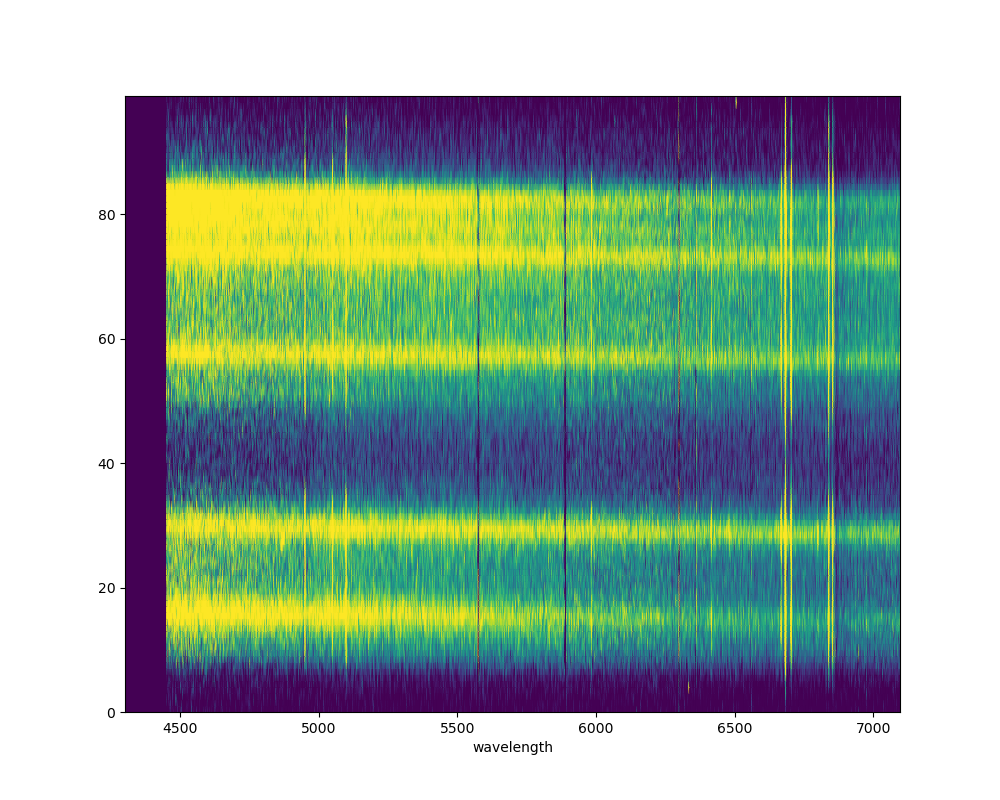

In [12]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [5]:
z = 0.0188
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_2/FORS2.2022-01-07T07_40_46.357/PSF/Real_seeing_UGC5823_2.txt")
sigmas = seeing / 2.35
print(sigmas)

[1.33512559 1.49517288 1.33275053 1.31702521 1.49096034 1.35106383]


In [6]:
l_HA

6686.3844

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_2/FORS2.2022-01-07T07_40_46.357/UGC-5823_2_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     373   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        54   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

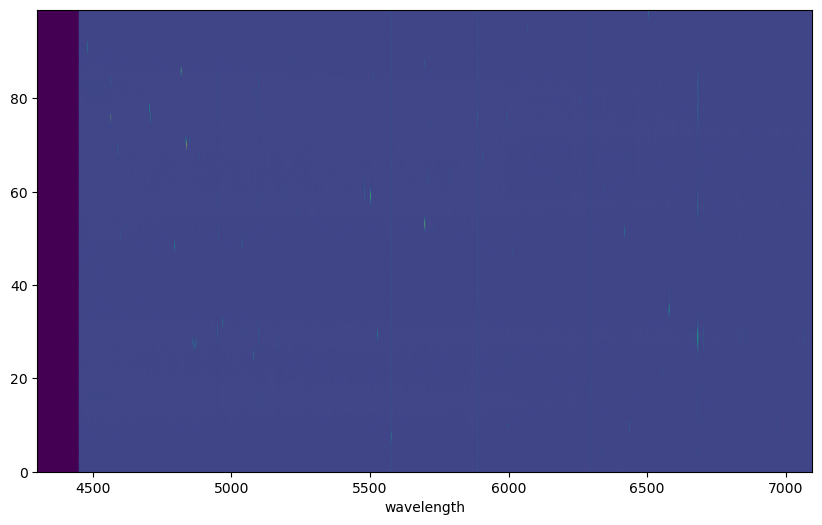

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_2/FORS2.2022-01-07T07_40_46.357/UGC-5823_2_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[38:138, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

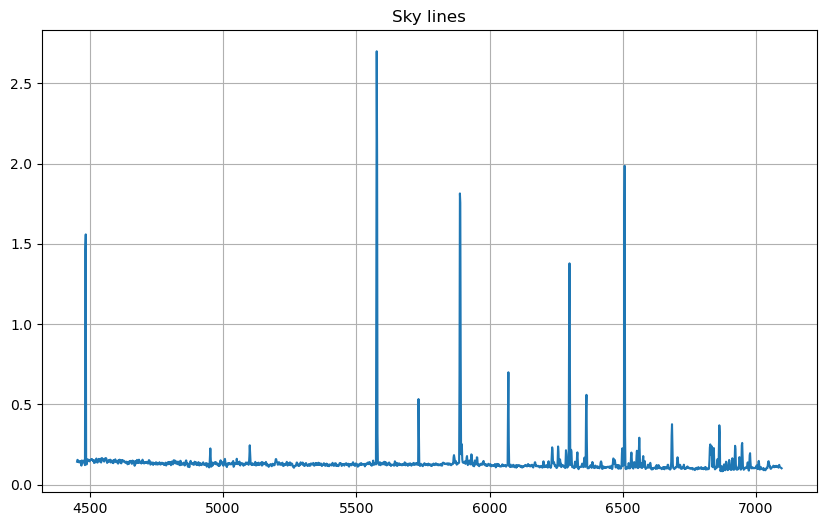

In [8]:
mask_sky = (y > 90)*(y < 100)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

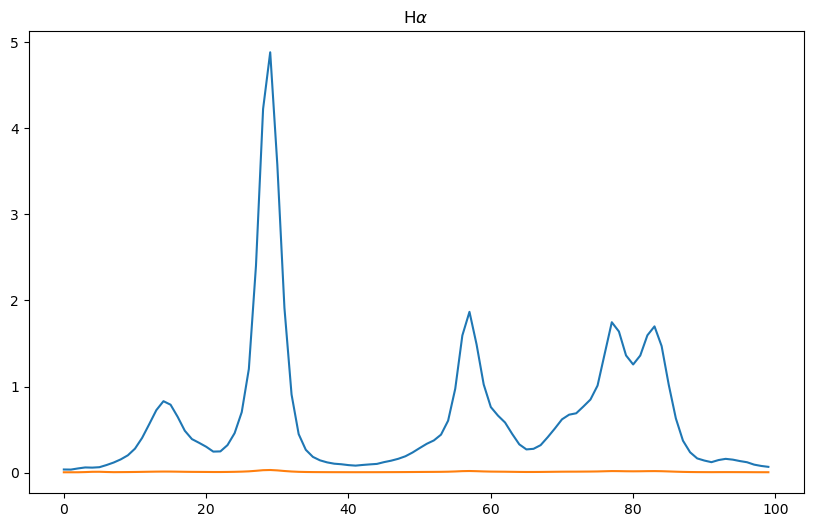

In [9]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_2/FORS2.2022-01-07T07_40_46.357/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [11]:
n_component = 7
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])+ 
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28])        
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'dodgerblue', linestyle='--', label='Sérsic 6')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 5.5)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'dodgerblue', linestyle='--', label='Sérsic 6')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 7)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (13, 16),   # x_0: posizione da 0 a 100

    (0, 20),
    (0, 50),
    (0.1, 10),
    (27, 30),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (55, 58),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (61, 62),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (70, 71.5),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (76, 79),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (81, 84),
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [12]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

differential_evolution step 1: f(x)= 480126.09565535444
differential_evolution step 2: f(x)= 187492.75338576603
differential_evolution step 3: f(x)= 68200.95777928905
differential_evolution step 4: f(x)= 68200.95777928905
differential_evolution step 5: f(x)= 68200.95777928905
differential_evolution step 6: f(x)= 68200.95777928905
differential_evolution step 7: f(x)= 68200.95777928905
differential_evolution step 8: f(x)= 47427.53117798199
differential_evolution step 9: f(x)= 35084.36763165504
differential_evolution step 10: f(x)= 35084.36763165504
differential_evolution step 11: f(x)= 35084.36763165504
differential_evolution step 12: f(x)= 35084.36763165504
differential_evolution step 13: f(x)= 35084.36763165504
differential_evolution step 14: f(x)= 29883.60521251973
differential_evolution step 15: f(x)= 29883.60521251973
differential_evolution step 16: f(x)= 29883.60521251973
differential_evolution step 17: f(x)= 18387.82356701667
differential_evolution step 18: f(x)= 18387.82356701667

In [13]:
print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.0844, r_e=9.6570, n=1.5999, x_0=14.3070
Sérsic 2: I_e=0.1870, r_e=5.4165, n=3.2650, x_0=28.8141
Sérsic 3: I_e=0.1419, r_e=7.0205, n=1.9587, x_0=56.9392
Sérsic 4: I_e=0.2332, r_e=0.6638, n=0.3527, x_0=61.3772
Sérsic 5: I_e=0.6472, r_e=0.1028, n=1.8795, x_0=70.2808
Sérsic 6: I_e=0.1793, r_e=11.7514, n=1.5099, x_0=77.5099
Sérsic 7: I_e=1.2258, r_e=1.0745, n=0.3371, x_0=83.2151
Chi quadro minimo: 0.20312143494388796
False


Sérsic 1: I_e=0.0844, r_e=9.6570, n=1.5999, x_0=14.3070
Sérsic 2: I_e=0.1870, r_e=5.4165, n=3.2650, x_0=28.8141
Sérsic 3: I_e=0.1419, r_e=7.0205, n=1.9587, x_0=56.9392
Sérsic 4: I_e=0.2332, r_e=0.6638, n=0.3527, x_0=61.3772
Sérsic 5: I_e=0.6472, r_e=0.1028, n=1.8795, x_0=70.2808
Sérsic 6: I_e=0.1793, r_e=11.7514, n=1.5099, x_0=77.5099
Sérsic 7: I_e=1.2258, r_e=1.0745, n=0.3371, x_0=83.2151


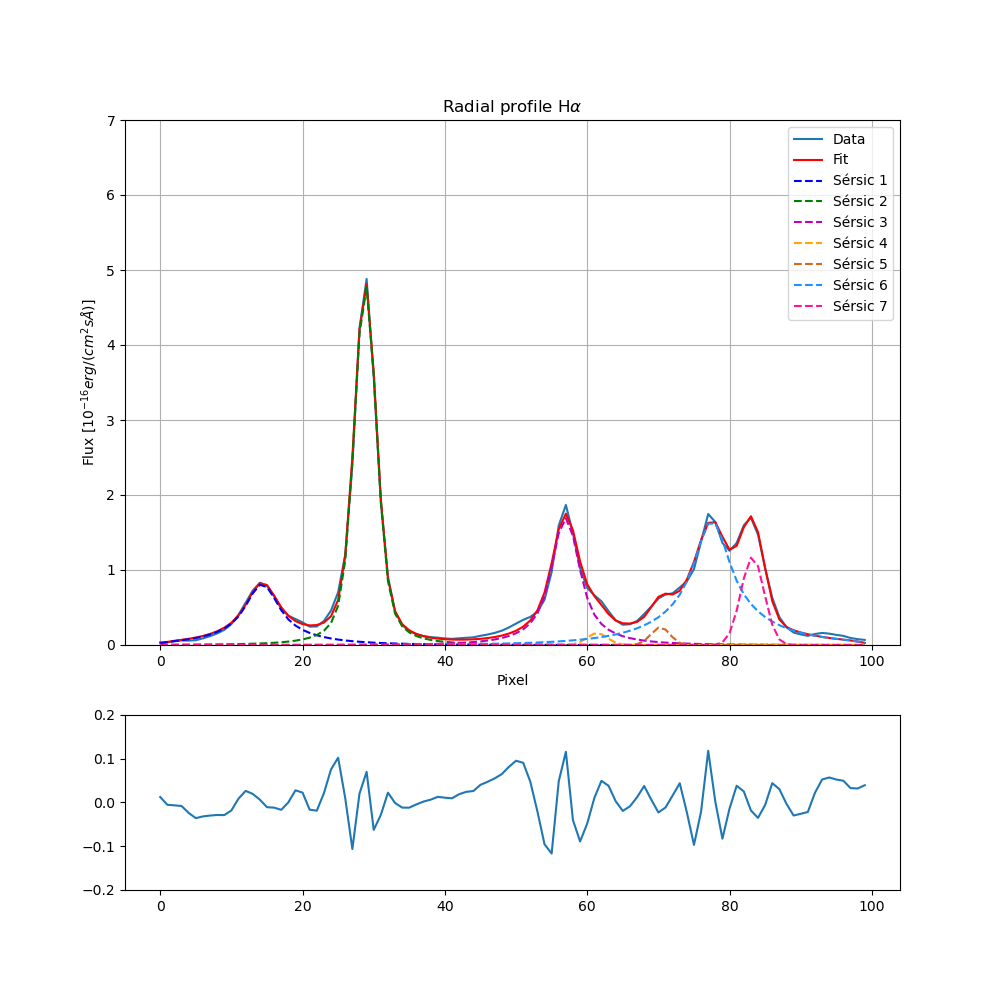

In [14]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [15]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA, bounds = bounds_list)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0794, r_e=9.4707, n=1.6742, x_0=14.2799
Sérsic 2: I_e=0.1844, r_e=5.6615, n=3.1760, x_0=28.7912
Sérsic 3: I_e=0.0843, r_e=10.1595, n=2.3081, x_0=56.9145
Sérsic 4: I_e=0.3494, r_e=0.4480, n=0.3642, x_0=61.4525
Sérsic 5: I_e=0.6109, r_e=0.1034, n=1.8726, x_0=70.2810
Sérsic 6: I_e=0.1340, r_e=14.1596, n=1.7010, x_0=77.4548
Sérsic 7: I_e=1.2054, r_e=1.2552, n=0.2582, x_0=83.1643
[3.55136657e-02 3.12989910e+00 3.29119405e-01 1.02240725e-01
 1.98674651e-01 3.51379295e+00 1.93504990e+00 2.34370677e-02
 1.08368620e-01 8.27374090e+00 1.57052834e+00 8.45406909e-03
 6.22535297e+01 2.21851437e+00 1.75550138e+02 3.98688848e-01
 3.27304600e+03 8.18721769e+01 7.02164342e+03 3.39469554e+00
 5.62051363e-02 3.63773957e+00 3.12738408e-01 1.56755101e-01
 1.15300805e+00 1.74214062e-01 9.05383683e-01 1.07385150e-01]
1.0574972363000594


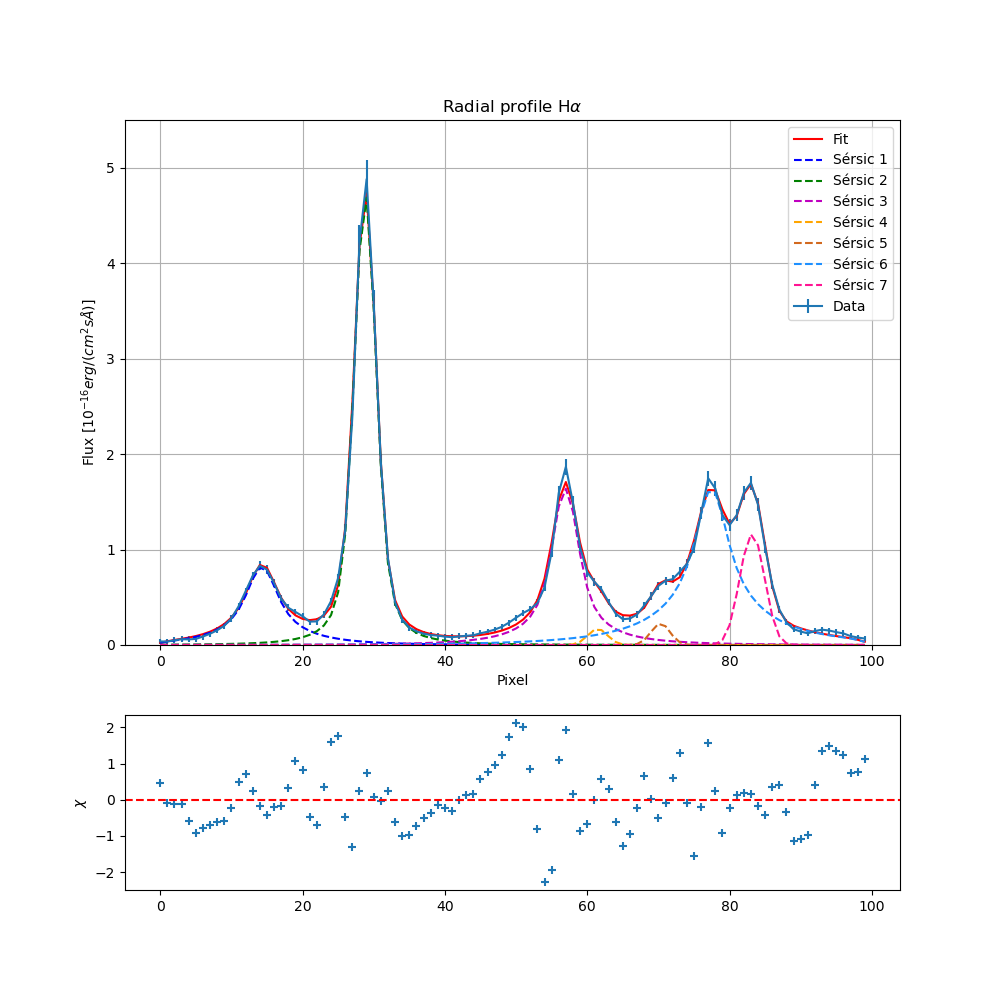

In [16]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [17]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (x_0_HA[4]-1.5, x_0_HA[4]+1.5),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.5, x_0_HA[5]+1.5),
    
    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[6]-1.5, x_0_HA[6]+1.5),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

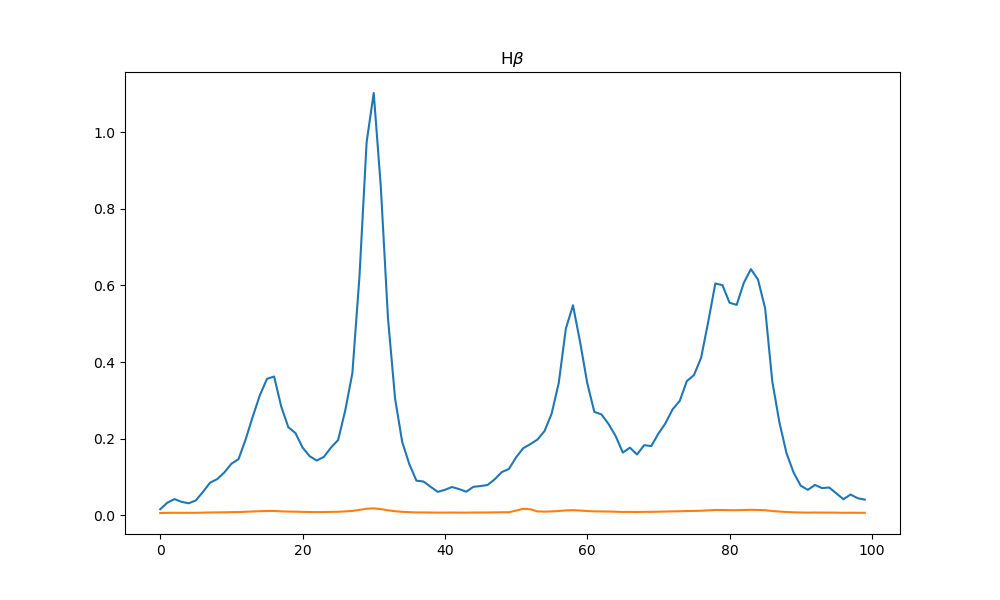

In [18]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[0])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [19]:
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1027668.1354900446
differential_evolution step 2: f(x)= 248841.495187047
differential_evolution step 3: f(x)= 111696.64680587378
differential_evolution step 4: f(x)= 64309.28139415475
differential_evolution step 5: f(x)= 64309.28139415475
differential_evolution step 6: f(x)= 64309.28139415475
differential_evolution step 7: f(x)= 50001.12169756129
differential_evolution step 8: f(x)= 50001.12169756129
differential_evolution step 9: f(x)= 26466.177423888144
differential_evolution step 10: f(x)= 26466.177423888144
differential_evolution step 11: f(x)= 26466.177423888144
differential_evolution step 12: f(x)= 26466.177423888144
differential_evolution step 13: f(x)= 15687.870570829187
differential_evolution step 14: f(x)= 15687.870570829187
differential_evolution step 15: f(x)= 15687.870570829187
differential_evolution step 16: f(x)= 15687.870570829187
differential_evolution step 17: f(x)= 15687.870570829187
differential_evolution step 18: f(x)= 15035.666

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15624\3205432239.py:10: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.0480, r_e=11.1388, n=1.3310, x_0=15.6120
Sérsic 2: I_e=0.2261, r_e=2.3901, n=1.6001, x_0=29.8065
Sérsic 3: I_e=0.0190, r_e=27.8622, n=2.1725, x_0=57.8305
Sérsic 4: I_e=0.0000, r_e=1.8690, n=0.5904, x_0=62.6322
Sérsic 5: I_e=0.4678, r_e=0.0173, n=3.6516, x_0=71.5923
Sérsic 6: I_e=0.0604, r_e=12.4821, n=1.4989, x_0=78.4054
Sérsic 7: I_e=0.1070, r_e=2.3479, n=1.4415, x_0=83.7259
Chi quadro minimo: 0.04084221433929018
False


Sérsic 1: I_e=0.0480, r_e=11.1388, n=1.3310, x_0=15.6120
Sérsic 2: I_e=0.2261, r_e=2.3901, n=1.6001, x_0=29.8065
Sérsic 3: I_e=0.0190, r_e=27.8622, n=2.1725, x_0=57.8305
Sérsic 4: I_e=0.0000, r_e=1.8690, n=0.5904, x_0=62.6322
Sérsic 5: I_e=0.4678, r_e=0.0173, n=3.6516, x_0=71.5923
Sérsic 6: I_e=0.0604, r_e=12.4821, n=1.4989, x_0=78.4054
Sérsic 7: I_e=0.1070, r_e=2.3479, n=1.4415, x_0=83.7259


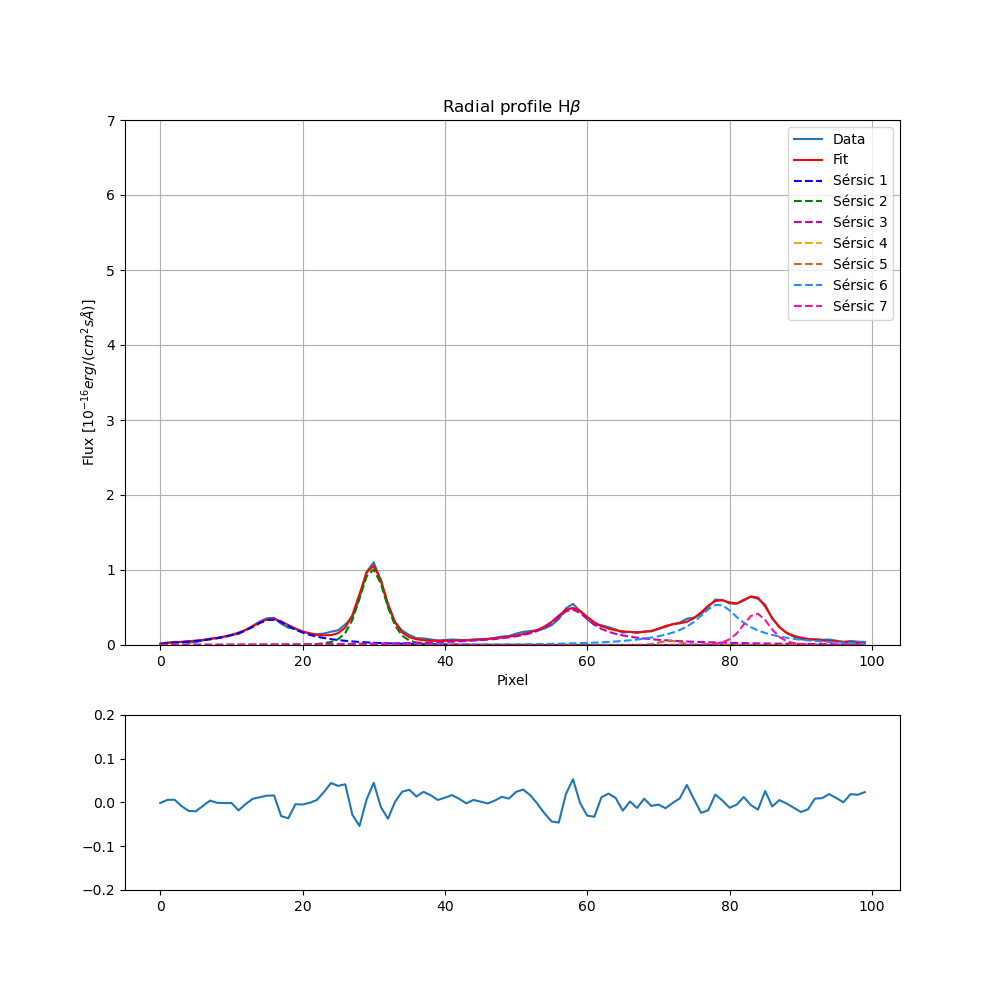

In [20]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [21]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0415, r_e=11.5554, n=1.4365, x_0=15.4069
Sérsic 2: I_e=0.0830, r_e=4.4937, n=2.4103, x_0=29.8065
Sérsic 3: I_e=0.0181, r_e=28.0400, n=2.2108, x_0=57.8579
Sérsic 4: I_e=0.0007, r_e=1.8676, n=0.5966, x_0=62.6324
Sérsic 5: I_e=0.4678, r_e=0.0171, n=3.6516, x_0=71.5921
Sérsic 6: I_e=0.0613, r_e=12.7582, n=1.4839, x_0=78.4201
Sérsic 7: I_e=0.1035, r_e=2.2709, n=1.5019, x_0=83.7417
[2.10061263e-02 4.52990727e+00 3.44874190e-01 1.61478688e-01
 1.65636109e-01 4.98955724e+00 3.83265902e+00 7.00265532e-03
 2.23316967e-02 3.00310306e+01 7.94251605e-01 3.95810133e-01
 1.55751871e-01 1.90951138e+02 1.71512827e+02 7.54686743e+01
 1.92702566e+05 6.59071428e+03 2.18041595e+06 9.23387771e+02
 3.98854487e-02 5.70795214e+00 4.53316821e-01 2.96902452e-01
 1.76399378e-01 2.31180003e+00 1.50289708e+00 1.59147406e-01]
0.227063668565975


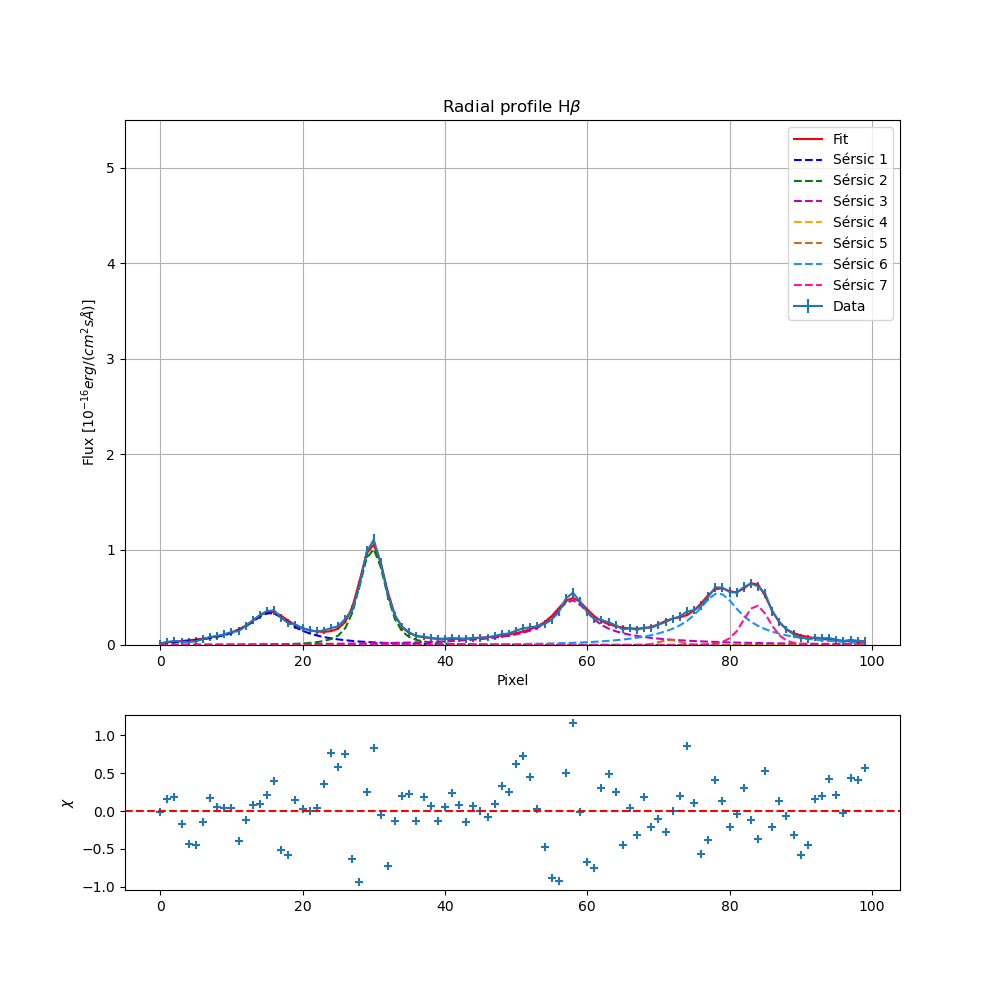

In [22]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

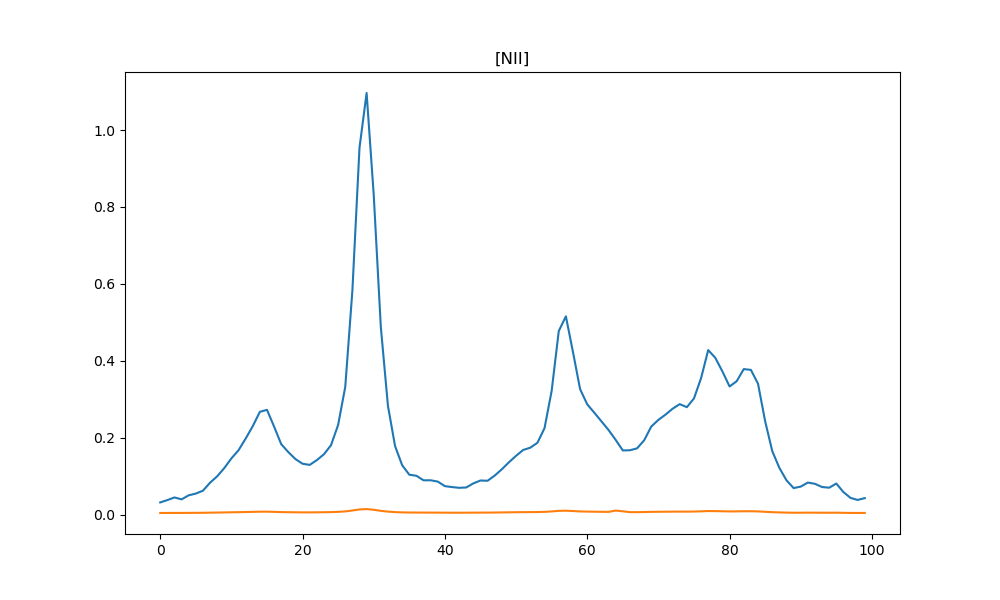

In [23]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [24]:
# Bounds:
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (x_0_HA[4]-1.5, x_0_HA[4]+1.5),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.5, x_0_HA[5]+1.5),
    
    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[6]-1, x_0_HA[6]+1),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 211497.6911713538
differential_evolution step 2: f(x)= 211497.6911713538
differential_evolution step 3: f(x)= 21985.366919498138
differential_evolution step 4: f(x)= 21985.366919498138
differential_evolution step 5: f(x)= 21985.366919498138
differential_evolution step 6: f(x)= 21985.366919498138
differential_evolution step 7: f(x)= 21985.366919498138
differential_evolution step 8: f(x)= 15775.967800562306
differential_evolution step 9: f(x)= 15775.967800562306
differential_evolution step 10: f(x)= 15775.967800562306
differential_evolution step 11: f(x)= 15775.967800562306
differential_evolution step 12: f(x)= 15775.967800562306
differential_evolution step 13: f(x)= 15775.967800562306
differential_evolution step 14: f(x)= 15775.967800562306
differential_evolution step 15: f(x)= 15775.967800562306
differential_evolution step 16: f(x)= 15775.967800562306
differential_evolution step 17: f(x)= 15775.967800562306
differential_evolution step 18: f(x)= 1577

Sérsic 1: I_e=0.0113, r_e=41.4691, n=1.9601, x_0=14.3789
Sérsic 2: I_e=0.1029, r_e=3.6663, n=2.1819, x_0=28.8657
Sérsic 3: I_e=0.0252, r_e=15.2811, n=1.9899, x_0=57.0403
Sérsic 4: I_e=0.0015, r_e=1.6215, n=6.5181, x_0=62.2037
Sérsic 5: I_e=0.0262, r_e=1.8886, n=1.2653, x_0=70.6482
Sérsic 6: I_e=0.0290, r_e=25.0677, n=1.6692, x_0=77.6116
Sérsic 7: I_e=0.1241, r_e=0.9592, n=0.9520, x_0=83.0259


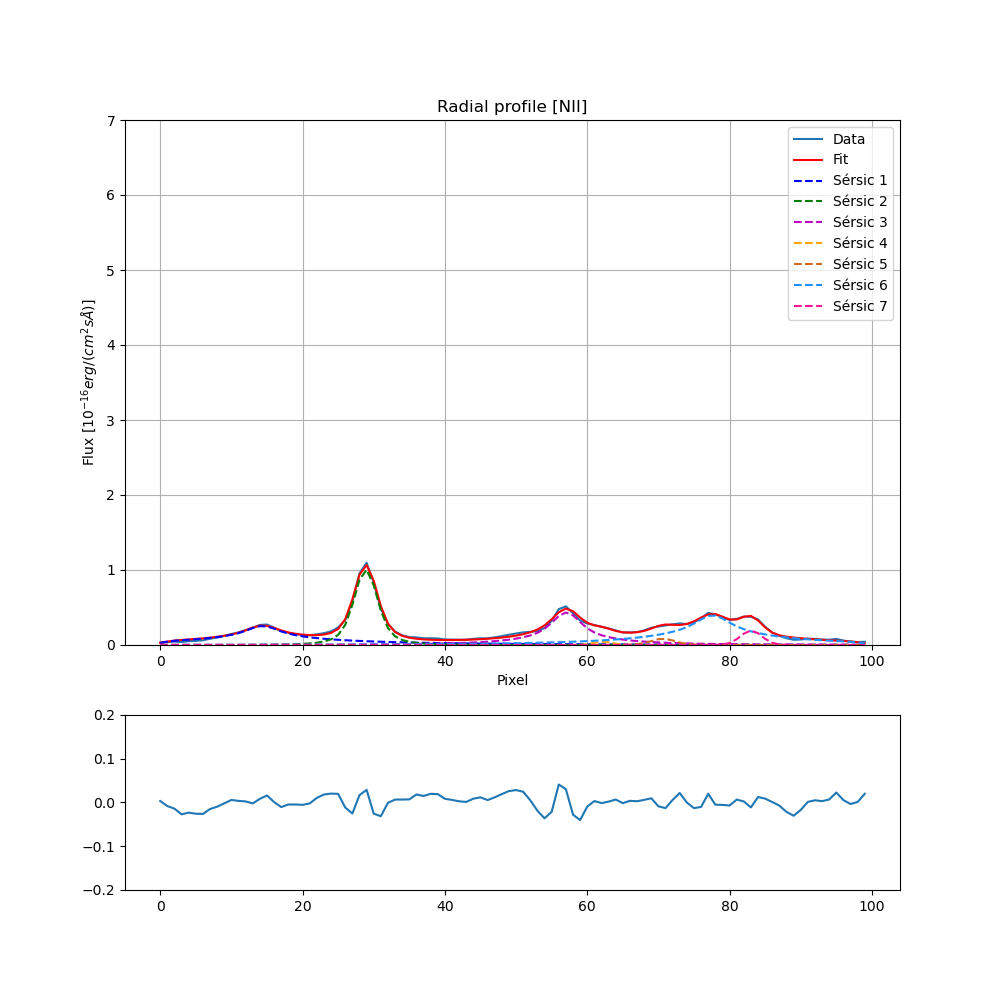

In [25]:
# Plots:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [26]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0101, r_e=41.4720, n=2.0728, x_0=14.3917
Sérsic 2: I_e=0.0927, r_e=4.0714, n=2.2230, x_0=28.8410
Sérsic 3: I_e=0.0261, r_e=15.4688, n=1.9379, x_0=56.9565
Sérsic 4: I_e=0.0013, r_e=1.6211, n=6.5181, x_0=62.2079
Sérsic 5: I_e=0.0260, r_e=1.9013, n=1.2589, x_0=70.6511
Sérsic 6: I_e=0.0288, r_e=25.1087, n=1.6713, x_0=77.5885
Sérsic 7: I_e=0.1243, r_e=0.9912, n=0.9459, x_0=83.0385
[9.59628567e-03 3.66028940e+01 6.11912286e-01 1.92500484e-01
 9.92706667e-02 2.40074871e+00 2.08617120e+00 7.79577816e-03
 2.44416880e-02 1.15067649e+01 6.22924884e-01 1.94852892e-01
 1.64751646e+00 1.08955235e+03 1.86102072e+03 7.34745337e-01
 3.37544214e-01 1.54375381e+01 1.05383012e+01 3.93951677e-01
 3.18857614e-02 2.05590541e+01 6.89655497e-01 3.55452672e-01
 5.96862669e-01 1.84649736e+00 4.59890289e+00 1.71748685e-01]
0.2813808516424299


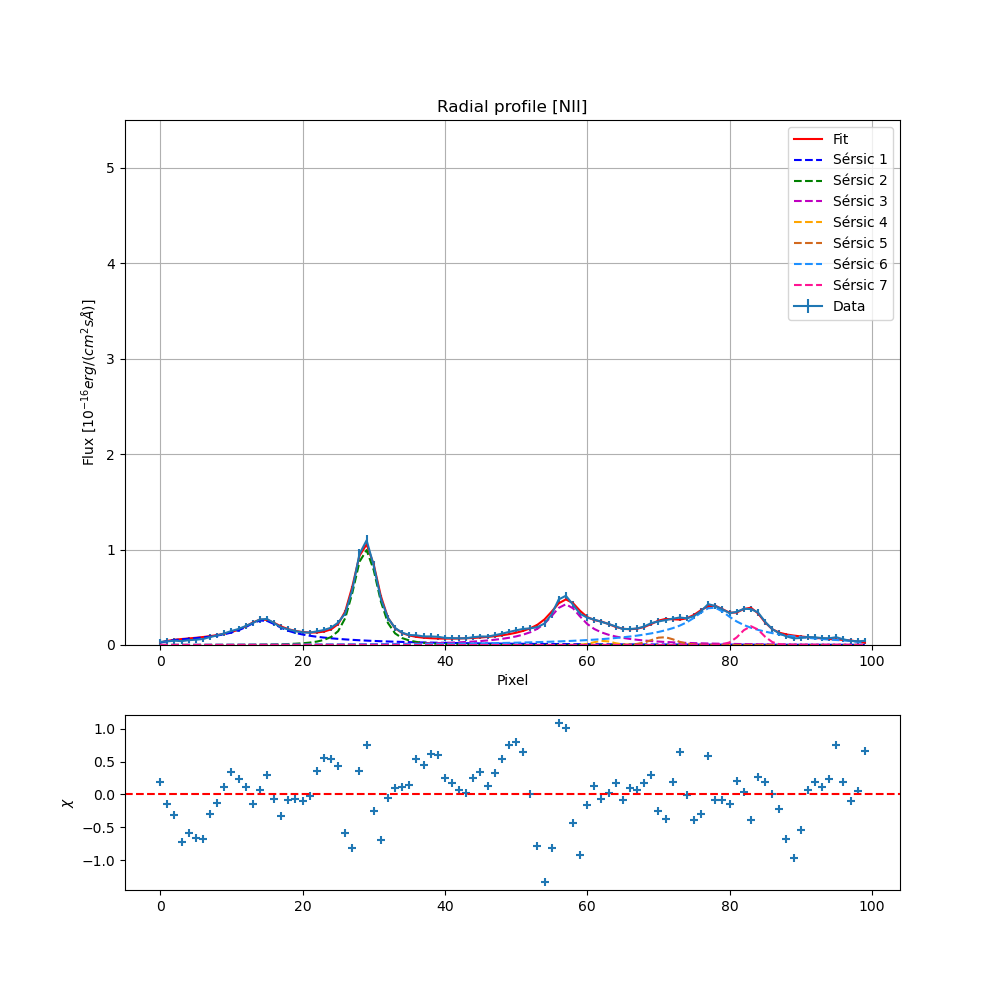

In [27]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

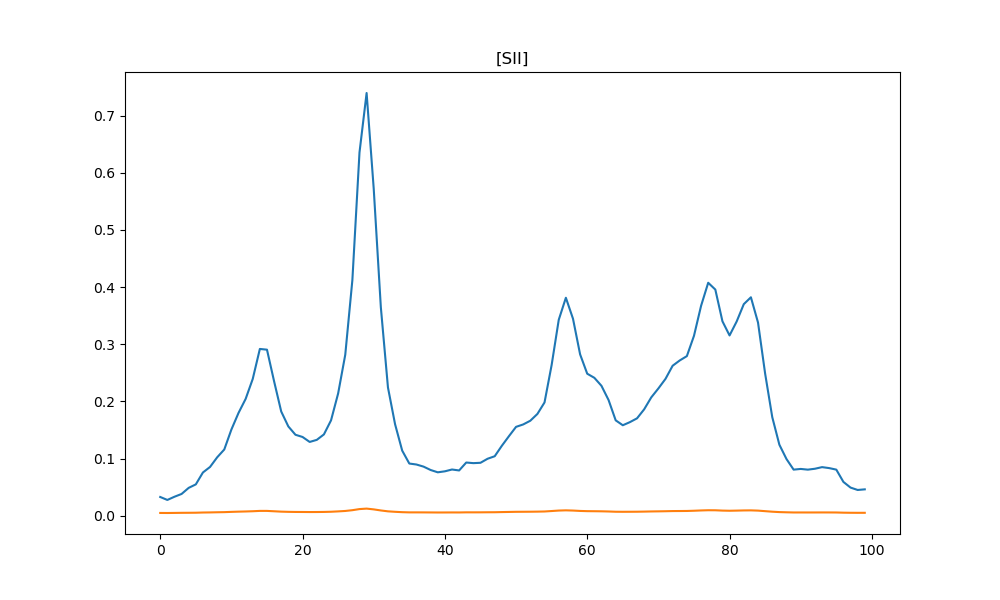

In [28]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[3])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [29]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 386188.09652471845
differential_evolution step 2: f(x)= 166195.90826698855
differential_evolution step 3: f(x)= 166195.90826698855
differential_evolution step 4: f(x)= 127850.12869938328
differential_evolution step 5: f(x)= 127850.12869938328
differential_evolution step 6: f(x)= 127850.12869938328
differential_evolution step 7: f(x)= 127850.12869938328
differential_evolution step 8: f(x)= 117317.9379149098
differential_evolution step 9: f(x)= 95005.5934723725
differential_evolution step 10: f(x)= 70585.47569125712
differential_evolution step 11: f(x)= 63927.97644898761
differential_evolution step 12: f(x)= 63927.97644898761
differential_evolution step 13: f(x)= 43046.64004715471
differential_evolution step 14: f(x)= 43046.64004715471
differential_evolution step 15: f(x)= 43046.64004715471
differential_evolution step 16: f(x)= 43046.64004715471
differential_evolution step 17: f(x)= 37798.08102093259
differential_evolution step 18: f(x)= 17232.9813163

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15624\3205432239.py:10: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.0210, r_e=20.8296, n=1.6625, x_0=14.3655
Sérsic 2: I_e=0.1168, r_e=3.2074, n=1.5486, x_0=28.8467
Sérsic 3: I_e=0.0309, r_e=15.7984, n=1.4841, x_0=57.0368
Sérsic 4: I_e=3.9481, r_e=0.0000, n=4.1999, x_0=61.5756
Sérsic 5: I_e=0.0376, r_e=0.0599, n=2.6501, x_0=71.2236
Sérsic 6: I_e=0.0226, r_e=33.7028, n=1.7910, x_0=77.3601
Sérsic 7: I_e=0.6658, r_e=0.2798, n=0.3719, x_0=83.1892
Chi quadro minimo: 0.020788608293370738
False


Sérsic 1: I_e=0.0210, r_e=20.8296, n=1.6625, x_0=14.3655
Sérsic 2: I_e=0.1168, r_e=3.2074, n=1.5486, x_0=28.8467
Sérsic 3: I_e=0.0309, r_e=15.7984, n=1.4841, x_0=57.0368
Sérsic 4: I_e=3.9481, r_e=0.0000, n=4.1999, x_0=61.5756
Sérsic 5: I_e=0.0376, r_e=0.0599, n=2.6501, x_0=71.2236
Sérsic 6: I_e=0.0226, r_e=33.7028, n=1.7910, x_0=77.3601
Sérsic 7: I_e=0.6658, r_e=0.2798, n=0.3719, x_0=83.1892


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15624\3205432239.py:10: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


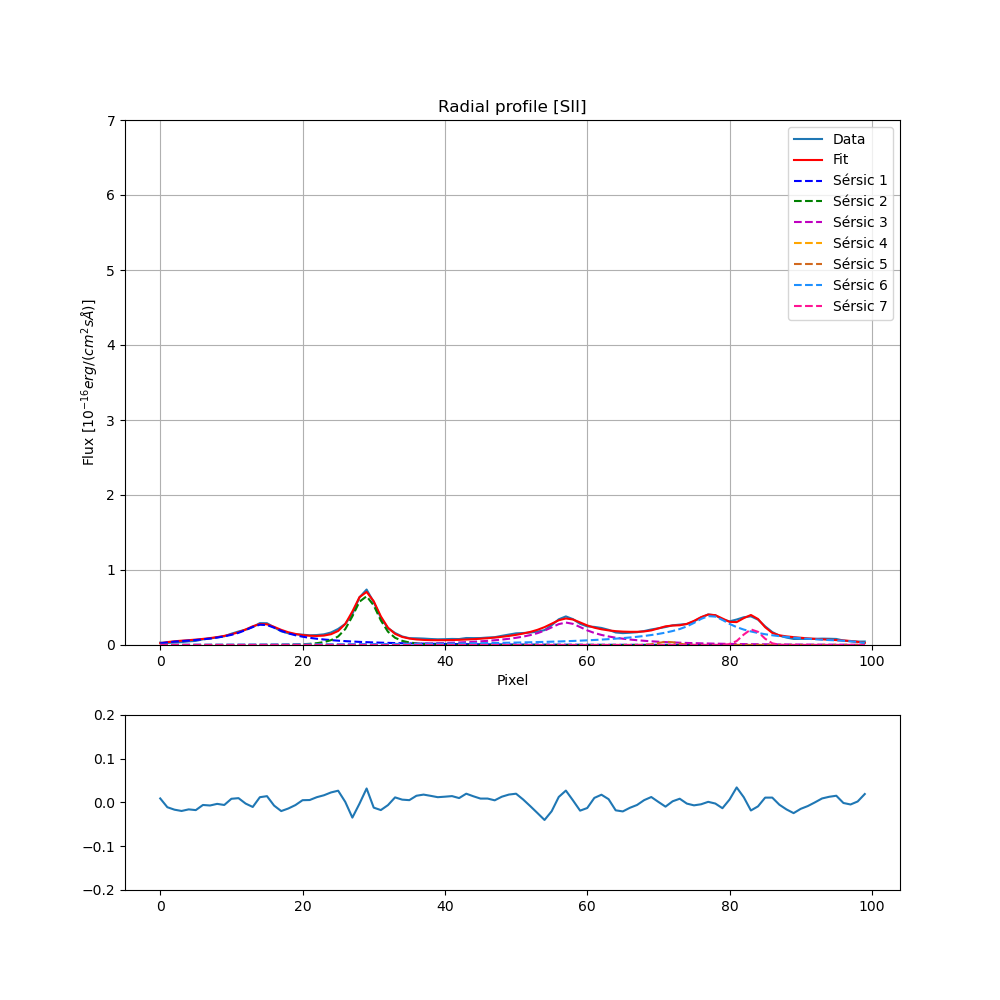

In [30]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [31]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0182, r_e=20.9444, n=1.7733, x_0=14.2773
Sérsic 2: I_e=0.0547, r_e=5.4340, n=2.1194, x_0=28.8410
Sérsic 3: I_e=0.0290, r_e=16.5770, n=1.5224, x_0=57.0877
Sérsic 4: I_e=3.9481, r_e=0.0000, n=4.1999, x_0=61.5756
Sérsic 5: I_e=0.0449, r_e=0.0636, n=2.6501, x_0=71.2236
Sérsic 6: I_e=0.0226, r_e=33.7633, n=1.7847, x_0=77.4035
Sérsic 7: I_e=0.6328, r_e=0.2955, n=0.3631, x_0=83.1078
[1.09587772e-02 1.09354023e+01 3.96850633e-01 1.46755238e-01
 7.26216838e-02 4.34801023e+00 1.91755677e+00 1.24776967e-02
 1.57902418e-02 8.68866195e+00 3.58370494e-01 1.36659749e-01
 5.46875402e-05 3.52523106e-05 5.31049255e-05 3.64420191e-05
 5.96641111e+03 2.16962543e+03 8.93900641e+04 2.72169649e+00
 1.58451285e-02 1.90114291e+01 4.52433770e-01 1.93845920e-01
 1.92443324e+02 3.30757962e+00 3.03958105e+02 1.04006852e-01]
0.21516136312350695


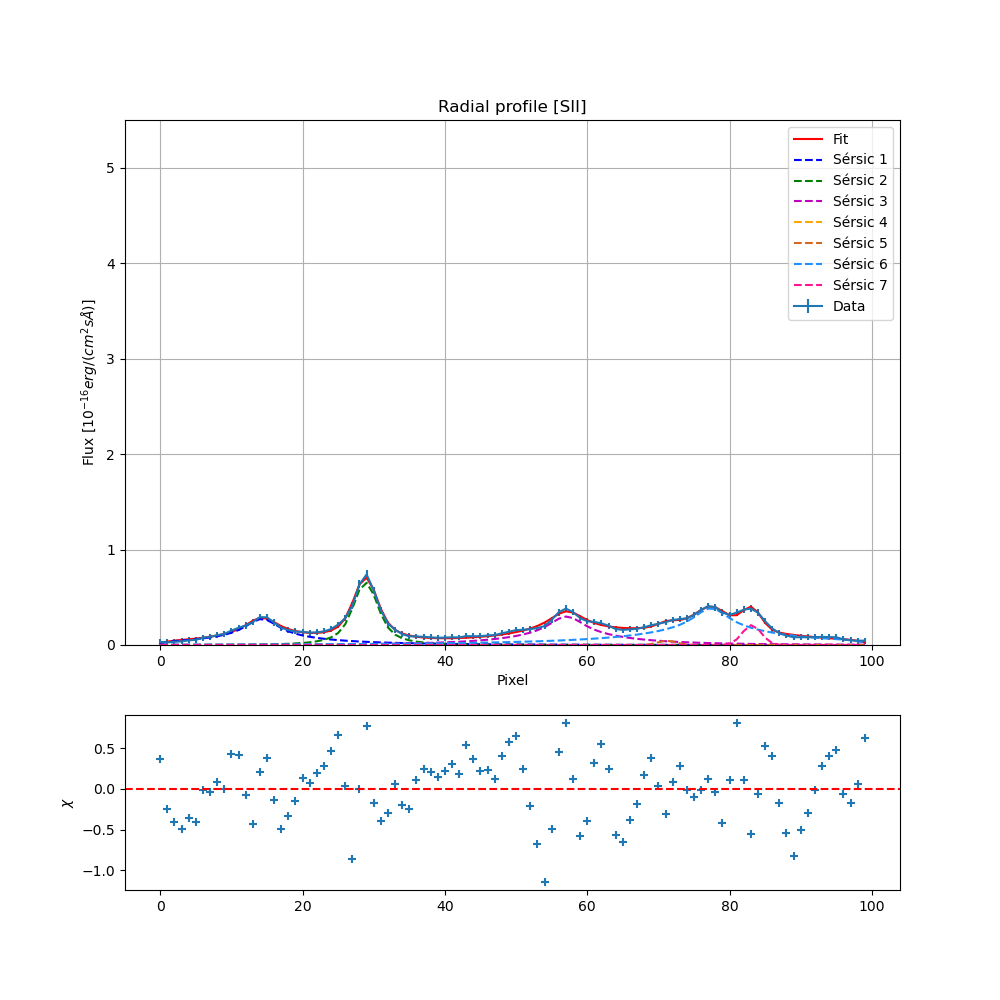

In [32]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

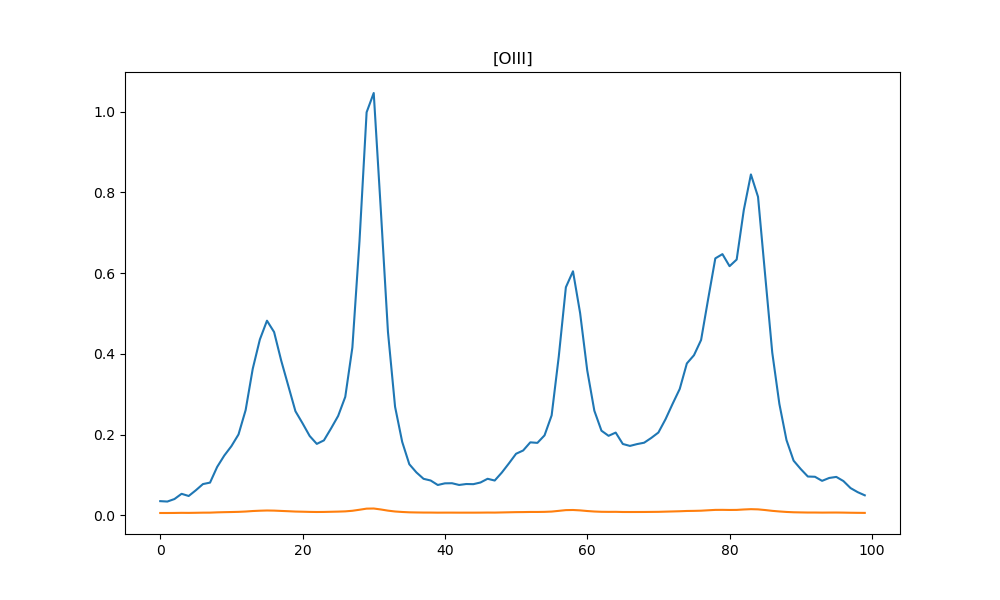

In [33]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[1])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [39]:
# Bounds:
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (20, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (x_0_HA[4]-1.5, x_0_HA[4]+1.5),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.5, x_0_HA[5]+1.5),
    
    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[6]-1, x_0_HA[6]+1),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 783628.8888825171
differential_evolution step 2: f(x)= 465416.80301258544
differential_evolution step 3: f(x)= 140596.38227581125
differential_evolution step 4: f(x)= 103051.48936219177
differential_evolution step 5: f(x)= 86835.62491459098
differential_evolution step 6: f(x)= 86835.62491459098
differential_evolution step 7: f(x)= 86835.62491459098
differential_evolution step 8: f(x)= 86835.62491459098
differential_evolution step 9: f(x)= 70377.36547116909
differential_evolution step 10: f(x)= 63470.05644414234
differential_evolution step 11: f(x)= 52751.42857233824
differential_evolution step 12: f(x)= 52751.42857233824
differential_evolution step 13: f(x)= 52751.42857233824
differential_evolution step 14: f(x)= 38893.3132182895
differential_evolution step 15: f(x)= 12301.323391874937
differential_evolution step 16: f(x)= 12301.323391874937
differential_evolution step 17: f(x)= 12301.323391874937
differential_evolution step 18: f(x)= 12301.32339187

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15624\3205432239.py:10: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.0244, r_e=22.1656, n=2.0052, x_0=14.9985
Sérsic 2: I_e=0.1115, r_e=3.9279, n=2.0506, x_0=29.5573
Sérsic 3: I_e=0.0283, r_e=12.7756, n=2.2301, x_0=57.7414
Sérsic 4: I_e=6.7120, r_e=0.0006, n=5.7929, x_0=61.2500
Sérsic 5: I_e=10.5121, r_e=0.0008, n=6.7587, x_0=69.3329
Sérsic 6: I_e=0.0930, r_e=13.7008, n=1.2253, x_0=78.8746
Sérsic 7: I_e=0.7082, r_e=0.2228, n=2.0625, x_0=83.5221
Chi quadro minimo: 0.06531598810227988
False


Sérsic 1: I_e=0.0244, r_e=22.1656, n=2.0052, x_0=14.9985
Sérsic 2: I_e=0.1115, r_e=3.9279, n=2.0506, x_0=29.5573
Sérsic 3: I_e=0.0283, r_e=12.7756, n=2.2301, x_0=57.7414
Sérsic 4: I_e=6.7120, r_e=0.0006, n=5.7929, x_0=61.2500
Sérsic 5: I_e=10.5121, r_e=0.0008, n=6.7587, x_0=69.3329
Sérsic 6: I_e=0.0930, r_e=13.7008, n=1.2253, x_0=78.8746
Sérsic 7: I_e=0.7082, r_e=0.2228, n=2.0625, x_0=83.5221


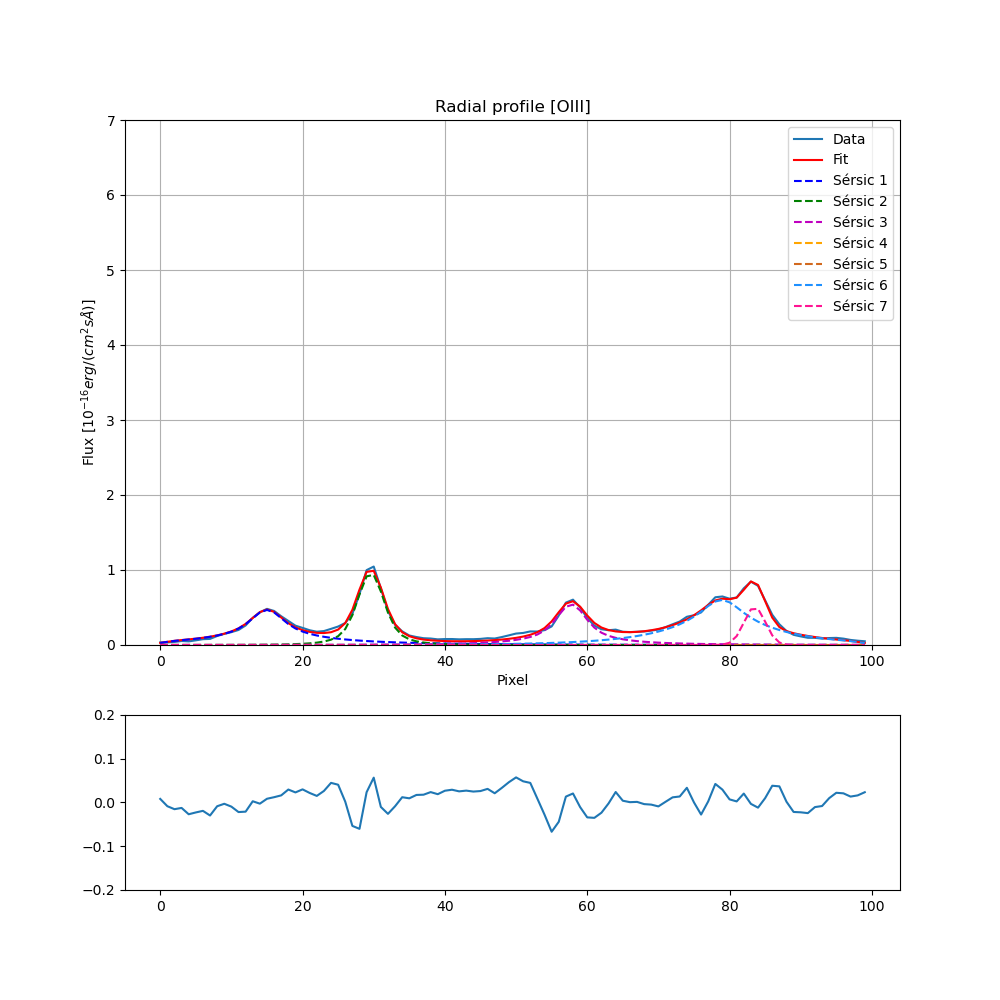

In [40]:
# Plots:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [45]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0239, r_e=22.3535, n=2.0272, x_0=15.2259
Sérsic 2: I_e=0.0541, r_e=6.1359, n=2.6520, x_0=29.6084
Sérsic 3: I_e=0.0255, r_e=14.1926, n=2.2295, x_0=57.7582
Sérsic 4: I_e=6.7119, r_e=0.0003, n=5.7927, x_0=61.3087
Sérsic 5: I_e=10.5120, r_e=0.0004, n=6.7585, x_0=69.3297
Sérsic 6: I_e=0.0843, r_e=14.7018, n=1.3120, x_0=78.9107
Sérsic 7: I_e=0.6314, r_e=0.2467, n=2.0300, x_0=83.5494
[1.80407905e-02 1.39743831e+01 5.22073192e-01 1.37976422e-01
 1.07427915e-01 7.35864202e+00 2.91726498e+00 4.03465287e-02
 3.73340041e-02 1.59694383e+01 1.03273993e+00 2.18199403e-01
 5.94363795e+06 3.13185765e+02 6.45236184e+06 2.52765208e+03
 1.07282532e+07 2.88860373e+02 6.69175763e+06 5.26657923e+02
 3.97722598e-02 4.99299449e+00 2.90577156e-01 4.71119466e-01
 8.09190633e+01 6.57454724e+00 1.85101974e+02 1.67489612e-01]
0.3458476332513109


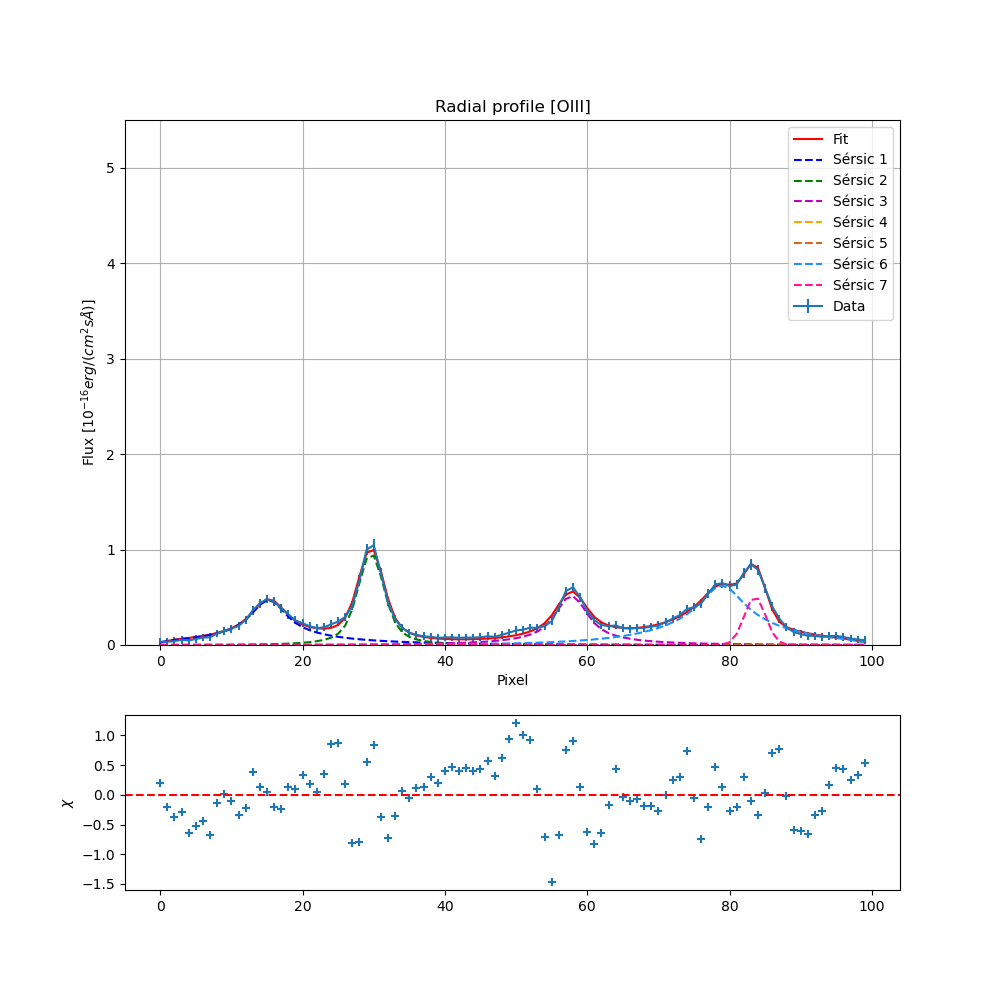

In [47]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [48]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

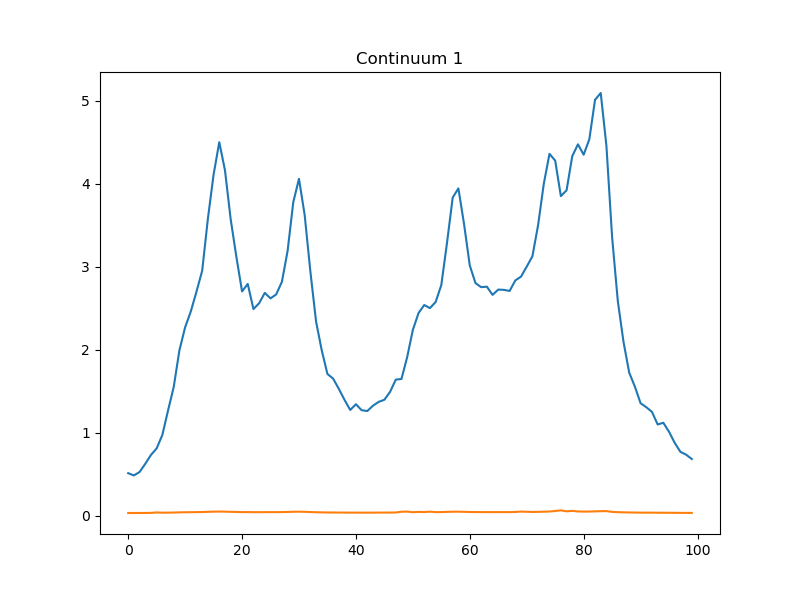

In [51]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[0])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [52]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 250436.04463752004
differential_evolution step 2: f(x)= 27770.286833520397
differential_evolution step 3: f(x)= 27770.286833520397
differential_evolution step 4: f(x)= 27770.286833520397
differential_evolution step 5: f(x)= 27700.06672324745
differential_evolution step 6: f(x)= 27700.06672324745
differential_evolution step 7: f(x)= 27700.06672324745
differential_evolution step 8: f(x)= 27700.06672324745
differential_evolution step 9: f(x)= 27700.06672324745
differential_evolution step 10: f(x)= 27700.06672324745
differential_evolution step 11: f(x)= 27700.06672324745
differential_evolution step 12: f(x)= 27700.06672324745
differential_evolution step 13: f(x)= 27700.06672324745
differential_evolution step 14: f(x)= 5181.357675962232
differential_evolution step 15: f(x)= 5181.357675962232
differential_evolution step 16: f(x)= 5181.357675962232
differential_evolution step 17: f(x)= 5181.357675962232
differential_evolution step 18: f(x)= 4655.5623794728

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15624\3205432239.py:10: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.8534, r_e=9.7224, n=0.9896, x_0=15.7525
Sérsic 2: I_e=0.1882, r_e=17.8924, n=1.9366, x_0=29.7944
Sérsic 3: I_e=0.2614, r_e=34.1809, n=1.5174, x_0=57.1163
Sérsic 4: I_e=0.0000, r_e=2.9899, n=1.2504, x_0=61.6745
Sérsic 5: I_e=1.5498, r_e=0.0016, n=4.2745, x_0=71.2972
Sérsic 6: I_e=0.8753, r_e=15.4831, n=0.9278, x_0=77.0990
Sérsic 7: I_e=1.3988, r_e=1.2815, n=0.8262, x_0=82.8715
Chi quadro minimo: 2.7634167894804413
False


In [53]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)    

Sérsic 1: I_e=0.8534, r_e=9.7224, n=0.9896, x_0=15.7525
Sérsic 2: I_e=0.1882, r_e=17.8924, n=1.9366, x_0=29.7944
Sérsic 3: I_e=0.2614, r_e=34.1809, n=1.5174, x_0=57.1163
Sérsic 4: I_e=0.0000, r_e=2.9899, n=1.2504, x_0=61.6745
Sérsic 5: I_e=1.5498, r_e=0.0016, n=4.2745, x_0=71.2972
Sérsic 6: I_e=0.8753, r_e=15.4831, n=0.9278, x_0=77.0990
Sérsic 7: I_e=1.3988, r_e=1.2815, n=0.8262, x_0=82.8715


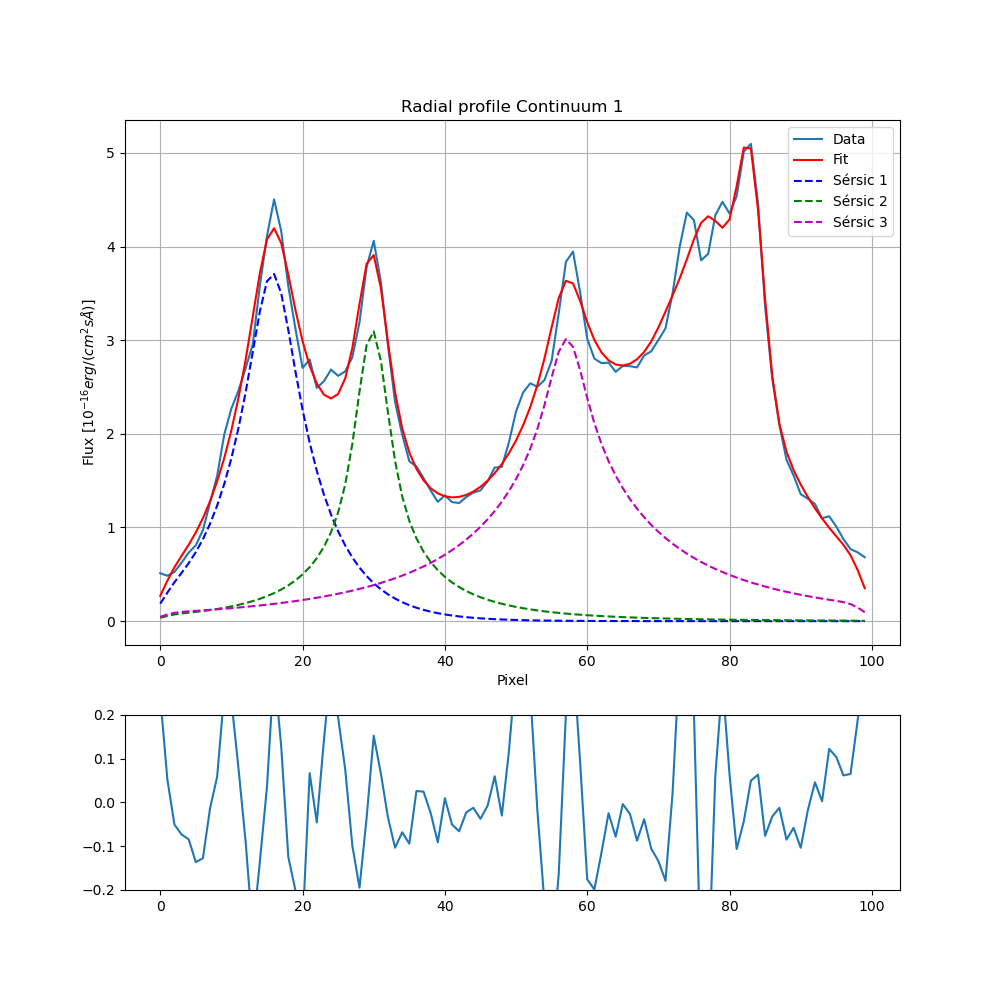

In [54]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [55]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.9934, r_e=8.8252, n=0.8881, x_0=15.7856
Sérsic 2: I_e=0.4977, r_e=7.1694, n=1.2695, x_0=29.7134
Sérsic 3: I_e=0.1801, r_e=48.0098, n=1.6955, x_0=57.1868
Sérsic 4: I_e=0.0000, r_e=0.2969, n=0.9241, x_0=61.8722
Sérsic 5: I_e=1.5638, r_e=0.0012, n=4.2700, x_0=71.2976
Sérsic 6: I_e=0.3439, r_e=31.8837, n=1.4559, x_0=76.0000
Sérsic 7: I_e=1.7412, r_e=1.9602, n=0.5107, x_0=82.5671
[2.30844941e-01 2.11217804e+00 1.66111163e-01 2.04370608e-01
 3.88793027e-01 4.75894961e+00 5.51490610e-01 1.71582051e-01
 2.42101774e-01 8.45607795e+01 8.52266749e-01 4.27664302e-01
 5.01877962e-01 1.62842775e-01 2.11870282e-01 1.89112367e-01
 1.35783326e+06 1.91306574e+04 3.33653740e+06 4.15891511e+03
 2.74226754e-01 3.02616029e+01 5.14237888e-01 7.11123177e-01
 1.21266974e+00 6.54744974e-01 5.86492065e-01 2.41650855e-01]
2.518780376564835


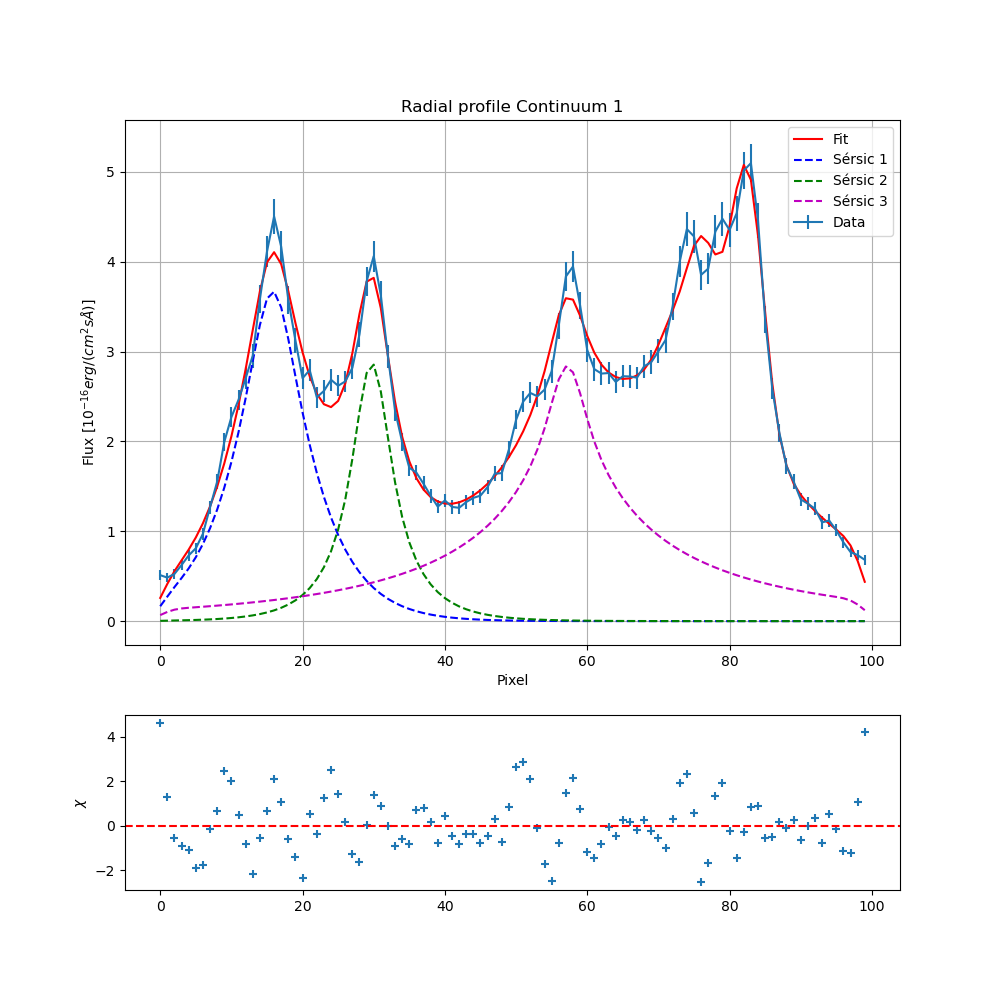

In [56]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

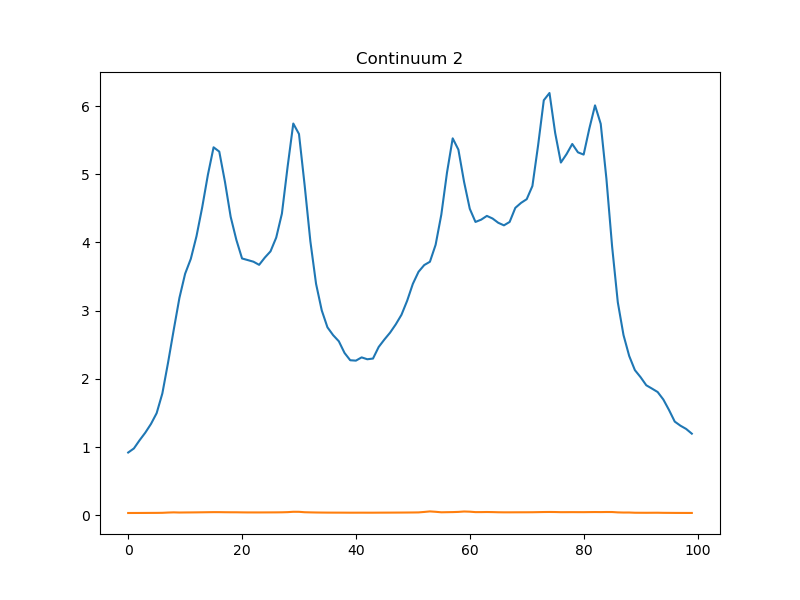

In [57]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

#x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [58]:
# Bounds:
bounds = bounds_HA
seeing_i = 3.174
sigma_i = seeing_i/ 2.35

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigma_i)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 134881.55258885308
differential_evolution step 2: f(x)= 134881.55258885308
differential_evolution step 3: f(x)= 134881.55258885308
differential_evolution step 4: f(x)= 27902.364575295596
differential_evolution step 5: f(x)= 27902.364575295596
differential_evolution step 6: f(x)= 27902.364575295596
differential_evolution step 7: f(x)= 27902.364575295596
differential_evolution step 8: f(x)= 26064.96257929215
differential_evolution step 9: f(x)= 26064.96257929215
differential_evolution step 10: f(x)= 26064.96257929215
differential_evolution step 11: f(x)= 26064.96257929215
differential_evolution step 12: f(x)= 6979.794930960056
differential_evolution step 13: f(x)= 6979.794930960056
differential_evolution step 14: f(x)= 6979.794930960056
differential_evolution step 15: f(x)= 6979.794930960056
differential_evolution step 16: f(x)= 6979.794930960056
differential_evolution step 17: f(x)= 6979.794930960056
differential_evolution step 18: f(x)= 6979.7949309

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15624\3205432239.py:10: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=1.1668, r_e=10.6358, n=0.8819, x_0=14.8636
Sérsic 2: I_e=0.3360, r_e=14.9529, n=1.6990, x_0=29.3361
Sérsic 3: I_e=0.4175, r_e=37.2270, n=1.3723, x_0=57.1497
Sérsic 4: I_e=0.7382, r_e=0.0000, n=1.5756, x_0=61.5483
Sérsic 5: I_e=0.5731, r_e=2.5986, n=0.1029, x_0=71.5000
Sérsic 6: I_e=0.5989, r_e=29.2644, n=1.2314, x_0=76.0000
Sérsic 7: I_e=1.6580, r_e=1.6949, n=0.4958, x_0=82.4125
Chi quadro minimo: 3.026161632085085
False


Sérsic 1: I_e=1.1668, r_e=10.6358, n=0.8819, x_0=14.8636
Sérsic 2: I_e=0.3360, r_e=14.9529, n=1.6990, x_0=29.3361
Sérsic 3: I_e=0.4175, r_e=37.2270, n=1.3723, x_0=57.1497
Sérsic 4: I_e=0.7382, r_e=0.0000, n=1.5756, x_0=61.5483
Sérsic 5: I_e=0.5731, r_e=2.5986, n=0.1029, x_0=71.5000
Sérsic 6: I_e=0.5989, r_e=29.2644, n=1.2314, x_0=76.0000
Sérsic 7: I_e=1.6580, r_e=1.6949, n=0.4958, x_0=82.4125


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15624\3205432239.py:10: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


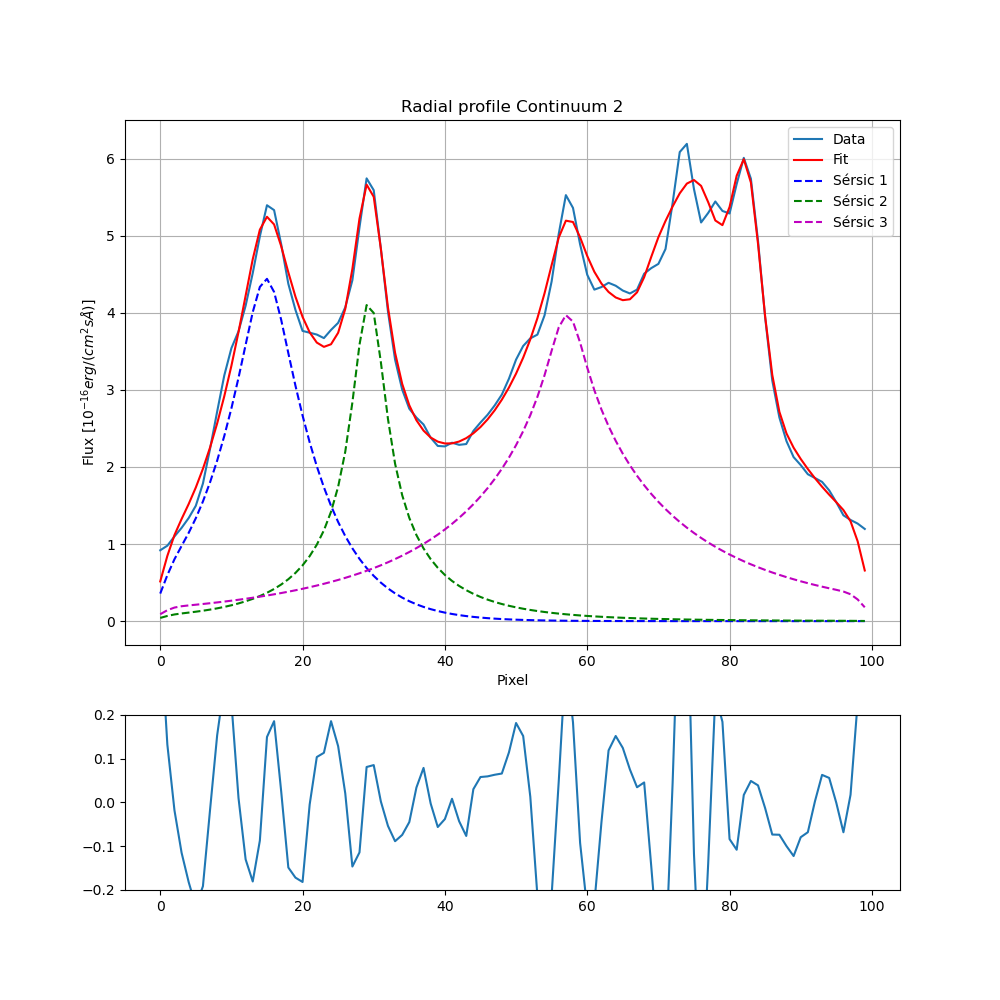

In [59]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigma_i,
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [60]:
bounds = bounds_HA
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigma_i, *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigma_i, x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.1940, r_e=9.8969, n=0.8714, x_0=14.9531
Sérsic 2: I_e=0.6650, r_e=7.5687, n=1.2314, x_0=29.2375
Sérsic 3: I_e=0.3717, r_e=49.9581, n=1.4500, x_0=57.4096
Sérsic 4: I_e=0.7382, r_e=0.0000, n=1.5756, x_0=61.5483
Sérsic 5: I_e=0.7106, r_e=3.0177, n=0.1000, x_0=71.5000
Sérsic 6: I_e=0.2759, r_e=49.8007, n=1.6360, x_0=76.0000
Sérsic 7: I_e=1.9382, r_e=1.8812, n=0.3928, x_0=82.2744
[2.93704302e-01 2.97406860e+00 1.79203219e-01 2.64518481e-01
 5.20158312e-01 5.34107557e+00 5.44770278e-01 1.94027736e-01
 3.71539578e-01 8.41081233e+01 6.68056178e-01 4.75336298e-01
 3.16067910e-12 1.39962731e-12 9.37421991e-14 9.39002126e-13
 4.16502528e+00 1.71997482e+01 1.82646076e+00 3.56319754e+00
 3.96530185e-01 9.47371874e+01 1.05922217e+00 1.97254167e+00
 1.52841757e+00 6.38603316e-01 6.58298358e-01 3.03313233e-01]
2.915437197798097


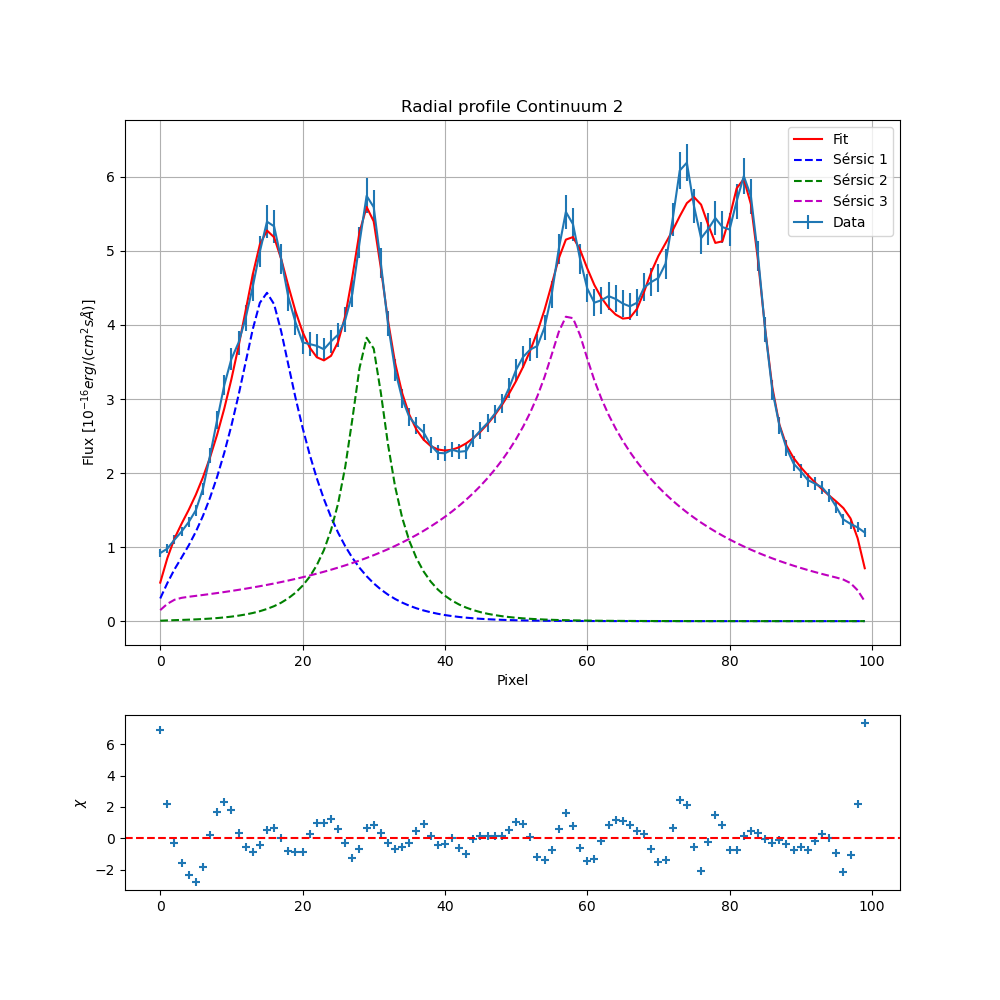

In [61]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

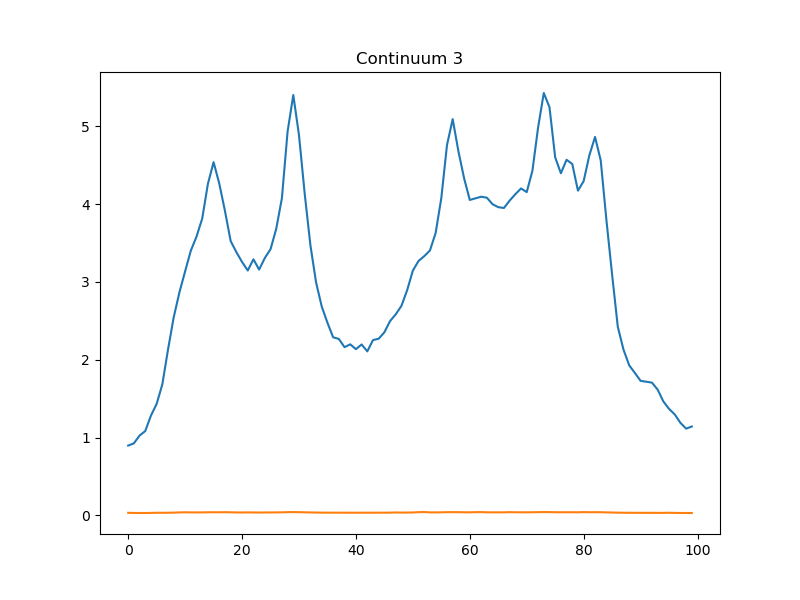

In [62]:
mask_continuum_3 = (wv > 6000)*(wv < 6500)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [63]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 476520.14266203763
differential_evolution step 2: f(x)= 380505.01427789155
differential_evolution step 3: f(x)= 142198.02930741734
differential_evolution step 4: f(x)= 52865.86503619637
differential_evolution step 5: f(x)= 52865.86503619637
differential_evolution step 6: f(x)= 52865.86503619637
differential_evolution step 7: f(x)= 52865.86503619637
differential_evolution step 8: f(x)= 52865.86503619637
differential_evolution step 9: f(x)= 49739.57617560149
differential_evolution step 10: f(x)= 15376.670609583542
differential_evolution step 11: f(x)= 15376.670609583542
differential_evolution step 12: f(x)= 15376.670609583542
differential_evolution step 13: f(x)= 12084.397873896714
differential_evolution step 14: f(x)= 7933.347064459032
differential_evolution step 15: f(x)= 7933.347064459032
differential_evolution step 16: f(x)= 7933.347064459032
differential_evolution step 17: f(x)= 7933.347064459032
differential_evolution step 18: f(x)= 7933.3470644

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15624\3205432239.py:10: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.8425, r_e=13.1883, n=0.9615, x_0=14.4871
Sérsic 2: I_e=0.3073, r_e=13.4612, n=1.7102, x_0=29.0638
Sérsic 3: I_e=0.6465, r_e=31.4905, n=1.2040, x_0=57.2162
Sérsic 4: I_e=1.3743, r_e=0.0000, n=5.2582, x_0=61.1674
Sérsic 5: I_e=0.7529, r_e=3.2948, n=0.1000, x_0=70.0000
Sérsic 6: I_e=1.9741, r_e=5.8761, n=0.1000, x_0=78.4496
Sérsic 7: I_e=0.9509, r_e=16.7396, n=0.1000, x_0=81.3134
Chi quadro minimo: 2.824642280216875
False


Sérsic 1: I_e=0.8425, r_e=13.1883, n=0.9615, x_0=14.4871
Sérsic 2: I_e=0.3073, r_e=13.4612, n=1.7102, x_0=29.0638
Sérsic 3: I_e=0.6465, r_e=31.4905, n=1.2040, x_0=57.2162
Sérsic 4: I_e=1.3743, r_e=0.0000, n=5.2582, x_0=61.1674
Sérsic 5: I_e=0.7529, r_e=3.2948, n=0.1000, x_0=70.0000
Sérsic 6: I_e=1.9741, r_e=5.8761, n=0.1000, x_0=78.4496
Sérsic 7: I_e=0.9509, r_e=16.7396, n=0.1000, x_0=81.3134


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15624\3205432239.py:10: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


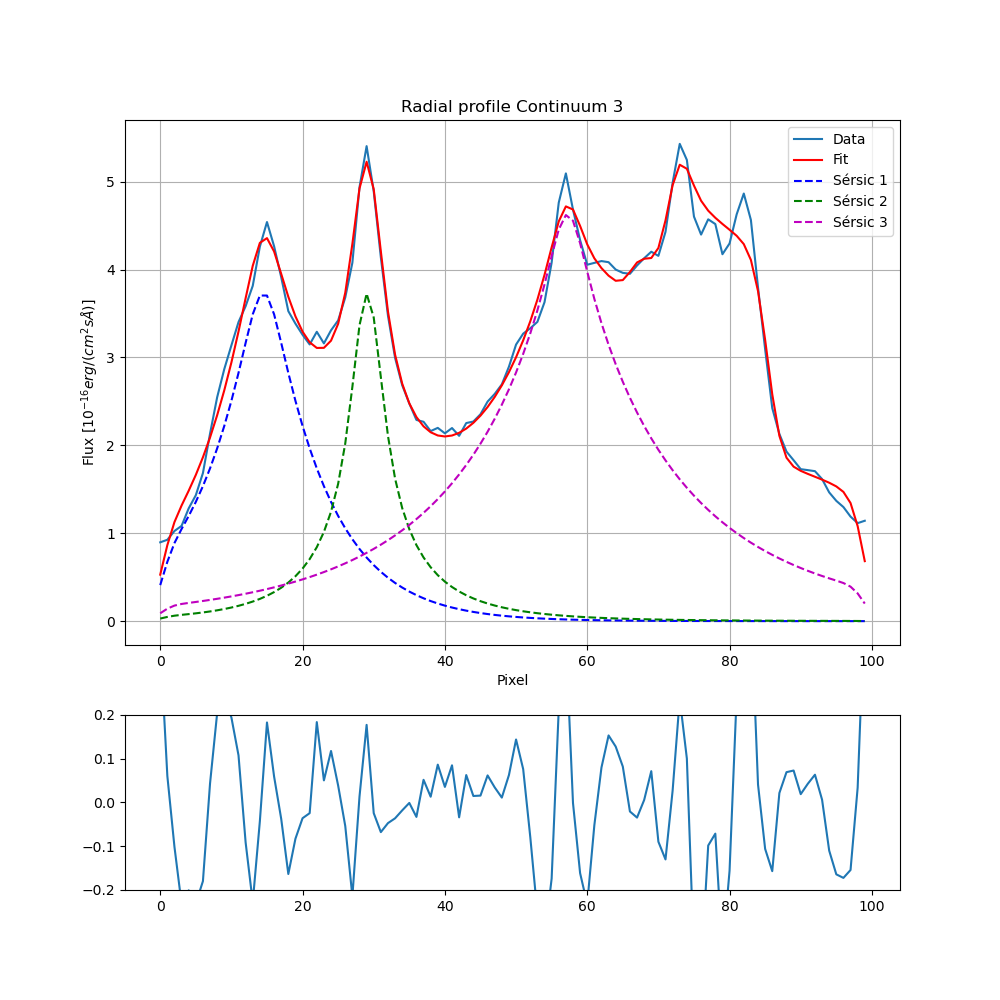

In [64]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [65]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.9498, r_e=10.9208, n=0.8740, x_0=14.4188
Sérsic 2: I_e=0.2566, r_e=16.2632, n=1.8318, x_0=29.0143
Sérsic 3: I_e=0.5842, r_e=36.4836, n=1.2481, x_0=57.3374
Sérsic 4: I_e=0.8772, r_e=0.0011, n=4.7547, x_0=61.0892
Sérsic 5: I_e=0.8107, r_e=3.3445, n=0.1000, x_0=70.0000
Sérsic 6: I_e=1.9712, r_e=5.8376, n=0.1000, x_0=78.4943
Sérsic 7: I_e=0.8325, r_e=18.2165, n=0.1000, x_0=82.6520
[2.69143835e-01 3.95754512e+00 2.03292718e-01 3.37330436e-01
 7.23931374e-01 4.70583105e+01 1.96497784e+00 1.93098002e-01
 7.01960206e-01 5.68734351e+01 7.84221708e-01 5.56492467e+00
 8.23552253e+05 1.11727018e+03 3.91320658e+06 1.23265459e+04
 3.10159946e+00 1.21313877e+01 1.12275410e+00 1.79894775e+00
 8.26949632e-01 2.47645345e+00 1.15597543e-01 4.57425545e-01
 1.94019644e+00 1.52135332e+01 6.04199975e-01 1.01574058e+01]
3.0986453296991914


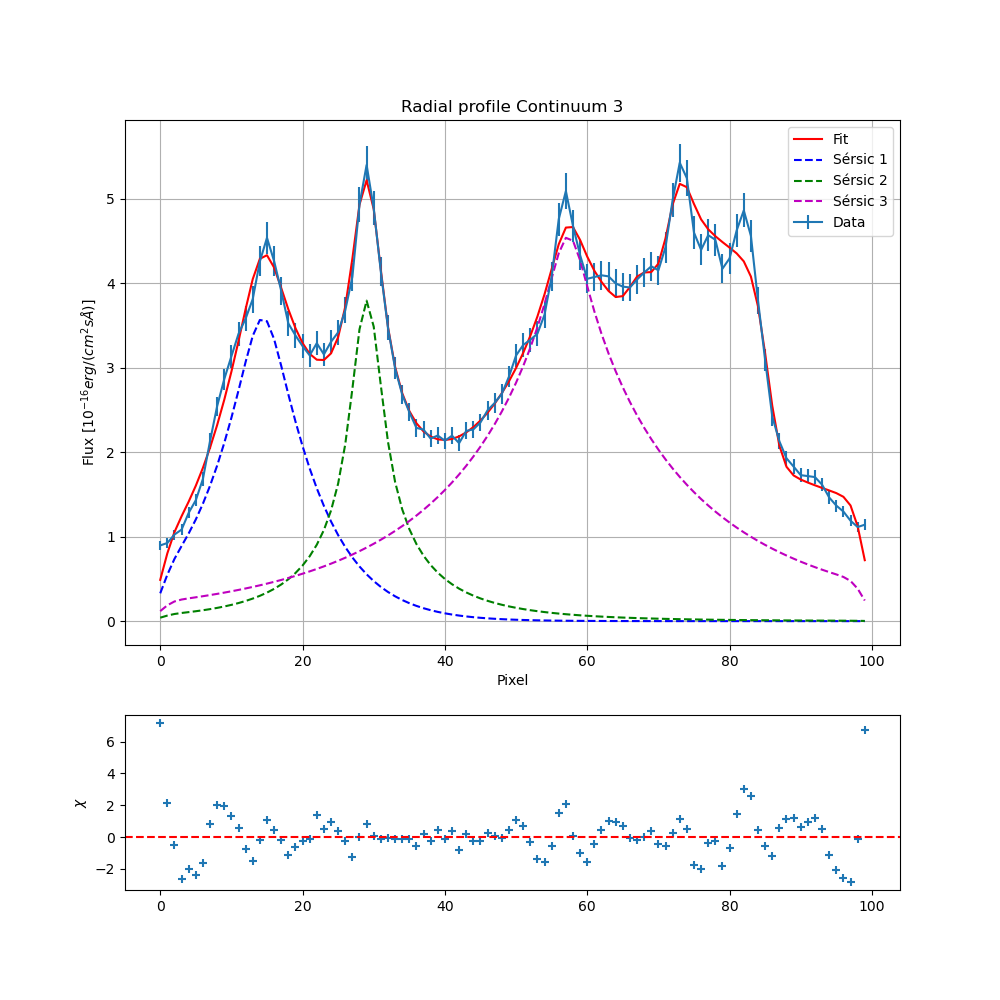

In [66]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

In [67]:
d1 = {'Name': ['Continuum 3'], 'Chi squared': chi2_continuum_3,
      'Dof': dof_continuum_3, 'Chi reduced': chi2_reduced_continuum_3}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_continuum_3.csv", index= False)

## Chi squared save

In [68]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

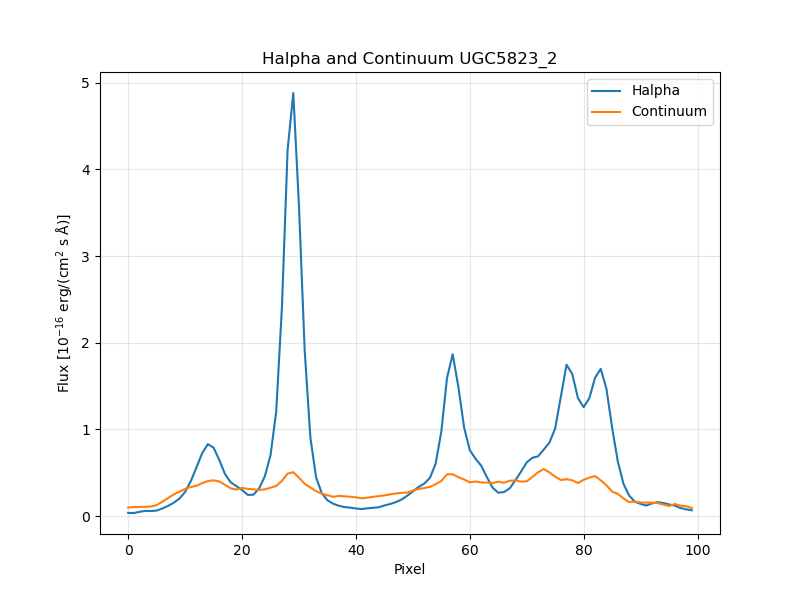

In [13]:
mask_continuum_3 = (wv > 6550)*(wv < 6600)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum UGC5823_2')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
plt.grid(alpha = 0.3)
plt.savefig('Halpha_continuum_UGC5823_2')